# Results

In [35]:
import difflib
import os
from pathlib import Path
import re

import flopy
import pandas as pd

In [ ]:
def read_conc_rtmf6(
    model_name,
    component_models_dir,
    components=('Na', 'Cl', 'K', 'Ca'),
    steps=None
):
    """Plot concentrations."""
    conc = {}
    for path in component_models_dir.glob('*'):
        name = path.name
        if name in components:
            value = pd.read_csv(
                path / f'gwt_{model_name}.obs.csv',
                nrows=steps,
                )[['time', 'CONCENTRATION']]
            value.columns = ['time', name]
            value[name] *= 1_000
            conc[name] = value
    res = conc[components[0]]
    for name in components[1:]:
        res = pd.merge(res, conc[name])
    return res.set_index('time')

In [69]:
def read_conc_pht3d(file_name):
    df = pd.read_csv(file_name, sep=r'\s+', index_col='time_d')
    df.index.name = 'time'
    return df

df_pht3d = read_conc_pht3d('pht3d/out.dat')

In [82]:
clean_df_pht3d = df_pht3d[df_pht3d.cell==40].drop(columns=['cell']) * 1_000

In [83]:
clean_df_pht3d

,Na,Ca,K,Cl
time,,,,
0.002,1.000000,0.00000,0.200000,0.0
0.004,1.000000,0.00000,0.200000,0.0
0.006,0.999990,0.00000,0.200000,0.0
0.008,0.999990,0.00000,0.200000,0.0
0.010,0.999990,0.00000,0.200000,0.0
...,...,...,...,...
0.232,0.000003,0.59997,0.000055,1.2
0.234,0.000002,0.59998,0.000044,1.2
0.236,0.000002,0.59998,0.000035,1.2


In [ ]:
df_rtmf6 = read_conc_rtmf6(
    model_name='cat_ex_1d',
    component_models_dir=Path('/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/rtmf6/.internal/component_models'))

In [168]:
df_rtmf6

,Na,Cl,K,Ca
time,,,,
0.001,0.996999,0.000000e+00,0.199400,1.981313e-17
0.002,0.996999,1.217936e-13,0.199400,3.976317e-17
0.003,0.996999,6.583367e-13,0.199400,6.005352e-17
0.004,0.996999,2.394274e-12,0.199400,8.291046e-17
0.005,0.996999,7.601381e-12,0.199400,1.155372e-16
...,...,...,...,...
0.236,0.000015,1.196419e+00,0.000053,5.981804e-01
0.237,0.000014,1.196419e+00,0.000049,5.981826e-01
0.238,0.000014,1.196419e+00,0.000045,5.981846e-01


In [ ]:
df_rtmf6_sel = df_rtmf6.loc[clean_df_pht3d.index]
diff = df_rtmf6_sel - clean_df_pht3d

In [100]:
rtmf6 = df_rtmf6_sel.copy()
pht3d = clean_df_pht3d.copy()

In [102]:
rtmf6.columns = [col + ' rtmf6' for col in rtmf6.columns]

In [103]:
rtmf6

,Na rtmf6,Cl rtmf6,K rtmf6,Ca rtmf6
time,,,,
0.002,0.996999,1.217936e-13,0.199400,3.976317e-17
0.004,0.996999,2.394274e-12,0.199400,8.291046e-17
0.006,0.996999,2.203633e-11,0.199400,1.553211e-16
0.008,0.996999,1.576185e-10,0.199400,2.032558e-16
0.010,0.996999,1.019186e-09,0.199400,3.790078e-16
...,...,...,...,...
0.232,0.000017,1.196418e+00,0.000076,5.981687e-01
0.234,0.000016,1.196418e+00,0.000063,5.981752e-01
0.236,0.000015,1.196419e+00,0.000053,5.981804e-01


In [104]:
pht3d.columns = [col + ' pht3d' for col in pht3d.columns]

In [109]:
joined = rtmf6.join(pht3d)

In [155]:
{species: f'C{n}' for n, species in enumerate(dict.fromkeys(col.split()[0] for col in joined.columns))}

{'Na': 'C0', 'Cl': 'C1', 'K': 'C2', 'Ca': 'C3'}

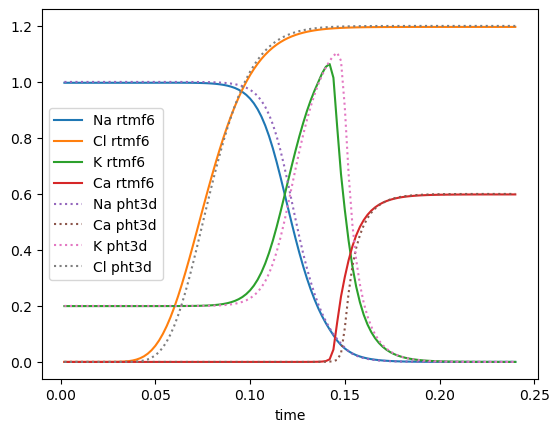

In [125]:
ax = joined.plot(style={name: ':' for name in joined.columns if name.endswith('pht3d')})

In [138]:
species_colors = {
    'Na': 'C0',   # blue
    'Cl': 'C1',   # orange
    'K': 'C2',    # green
    'Ca': 'C3'    # red
}

styles = []
for col in joined.columns:
    species = col.split()[0]
    linestyle = '-' if 'rtmf6' in col else '--'
    styles.append(f'{species_colors[species]}{linestyle}')

In [ ]:
def plot_joined(joined):
    species_colors = {
        species: f'C{n}' for n, species in
        enumerate(dict.fromkeys(col.split()[0] for col in joined.columns))}
    line_styles = {'rtmf6': '-', 'pht3d': '--'}
    styles = []
    for col in joined.columns:
        species, model_type = col.split()
        styles.append(f'{species_colors[species]}{line_styles[model_type]}')
    return joined.plot(style=styles)

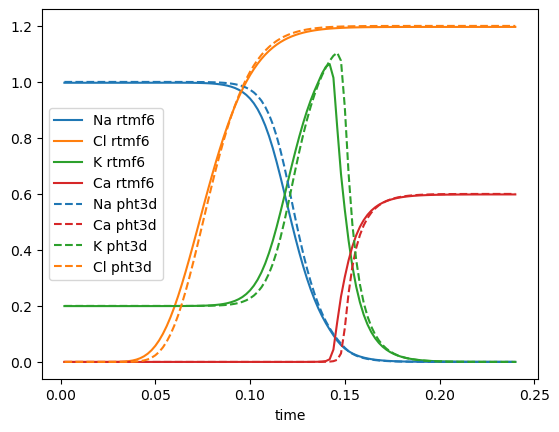

In [161]:
plot_joined(joined);

In [149]:
styles = [f'{species_colors[col.split()[0]]}{line_styles[col.split()[1]]}' for col in joined.columns]
styles

['C0-', 'C1-', 'C2-', 'C3-', 'C0--', 'C3--', 'C2--', 'C1--']

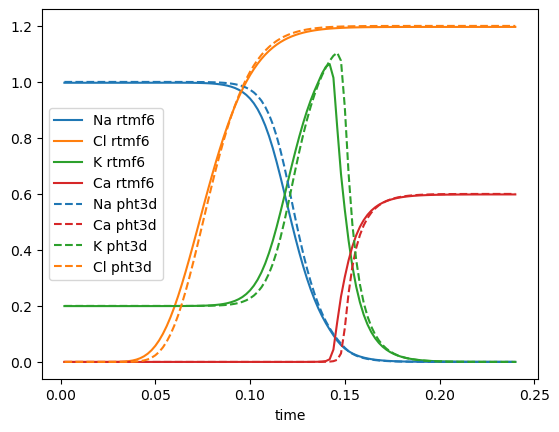

In [160]:
joined.plot(style=styles);

In [98]:
diff.describe()

,Ca,Cl,K,Na
count,1.200000e+02,120.000000,120.000000,120.000000
mean,6.831451e-03,0.004882,-0.005590,-0.011464
std,3.061403e-02,0.021294,0.067382,0.023390
min,-2.091465e-03,-0.014373,-0.404975,-0.094656
25%,-1.799499e-03,-0.004401,-0.000600,-0.005378
50%,1.049743e-12,-0.003588,0.000023,-0.002958
75%,1.911057e-07,0.000467,0.001666,0.000025
max,2.031355e-01,0.070040,0.091500,0.001855


In [99]:
clean_df_pht3d.describe()

,Na,Ca,K,Cl
count,120.000000,120.000000,120.000000,120.000000
mean,0.518192,0.214144,0.253334,0.802148
std,0.467866,0.278612,0.290359,0.511752
min,0.000001,0.000000,0.000023,0.000000
25%,0.001171,0.000000,0.017492,0.156700
50%,0.606230,0.000001,0.200000,1.170750
75%,0.999923,0.590697,0.221882,1.199900
max,1.000000,0.599990,1.104200,1.200000


<Axes: xlabel='time'>

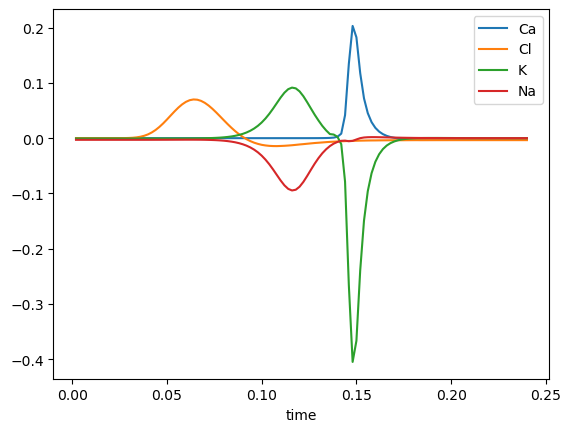

In [96]:
diff.plot()

,Ca,Cl,K,Na
time,,,,
0.001,False,False,False,False
0.002,True,True,True,True
0.003,False,False,False,False
0.004,True,True,True,True
0.005,False,False,False,False
...,...,...,...,...
0.236,True,True,True,True
0.237,False,False,False,False
0.238,True,True,True,True


In [ ]:

def plot(
    model_name,
    component_models_dir,
    components=('Na', 'Cl', 'K', 'Ca'),
    steps=None
):
    """Plot concentrations."""
    conc = {}
    for path in component_models_dir.glob('*'):
        name = path.name
        if name in components:
            value = pd.read_csv(
                path / f'gwt_{model_name}.obs.csv',
                nrows=steps,
                )[['time', 'CENTER_LAYER_0']]
            value.columns = ['time', name]
            value[name] *= 1_000
            conc[name] = value
    res = conc[components[0]]
    for name in components[1:]:
        res = pd.merge(res, conc[name])
    return res.plot(x='time', ylabel='mmols/kgw')

In [23]:
nlay = 1  # Number of layers
Lx = 0.08 #m Length of domain in x-direction (ncol * delr)
ncol = 40 # Number of columns
nrow = 1  # Number of rows
delr = Lx/ncol # Column spacing along a row ($m$)
tstep = 0.002 * 0.5

In [24]:
def find_closest_match(query, dictionary):
    closest_match = difflib.get_close_matches(query, dictionary.keys(), n=1)
    if closest_match:
        return closest_match[0]
    else:
        return None

<class 'pandas.core.frame.DataFrame'>
Index: 4800 entries, 0.002 to 0.24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cell    4800 non-null   float64
 1   Na      4800 non-null   float64
 2   Ca      4800 non-null   float64
 3   K       4800 non-null   float64
 4   Cl      4800 non-null   float64
dtypes: float64(5)
memory usage: 225.0 KB


In [ ]:
## Read pht3d results

wd = 'pht3d'
# dx = 0.01
simdf = pd.read_csv(os.path.join(wd, 'out.dat'), sep = '\t', skipinitialspace=True, index_col=[0])
simdf.drop(simdf.columns[len(simdf.columns)-1], axis=1, inplace=True)

simdf.loc[:, 'x'] = simdf['cell'] * delr

simapi = pd.read_csv(os.path.join('mf6rtm','sout.csv'), sep = ',', skipinitialspace=True, index_col=[0])
simapi.loc[:, 'x'] = (simapi['cell'] + 1)*delr

#offset index of simapi by tstep
simapi.index = simapi.index + tstep

simapi

# get all ucn files in wd
ucn_files = [f for f in os.listdir(wd) if f.lower().endswith('.ucn')]
ucn_files

# get file that ends in py
pht3dpy = [f for f in os.listdir(wd) if f.endswith('py')]

#read pht3dpy file
ucndic = {}
pht3dpy = os.path.join(wd, pht3dpy[0])
with open(pht3dpy, 'r') as f:
    # print(f.read())
    for l in f:
        n =re.findall(r'\d+', l.split()[-1])[-1]
        ucndic[l.split()[0].replace('_', "")] = f"PHT3D{n}.UCN"

for k,v in ucndic.items():
    ucn = flopy.utils.HeadFile(os.path.join(wd, v),text=f"concentration")
    results = ucn.get_alldata()
    ucndic[k] = results
timespht3d = ucn.get_times()

for var in simapi.columns:
    closest_match = find_closest_match(var, ucndic)
    if closest_match:
        ucndic[var] = ucndic.pop(closest_match)


In [53]:
ucndic.keys()

dict_keys(['N5', 'pH', 'pe', 'CaX2', 'KX', 'NaX', 'Na', 'Ca', 'K', 'Cl'])

In [51]:
simdf

,cell,Na,Ca,K,Cl,x
time_d,,,,,,
0.002,1.0,8.468700e-04,4.273300e-06,3.443900e-04,0.000669,0.002
0.002,2.0,9.416900e-04,5.696300e-07,2.570900e-04,0.000347,0.004
0.002,3.0,9.831200e-04,1.017400e-07,2.166500e-04,0.000121,0.006
0.002,4.0,9.945800e-04,2.840500e-08,2.053500e-04,0.000041,0.008
0.002,5.0,9.982100e-04,8.975600e-09,2.017700e-04,0.000014,0.010
...,...,...,...,...,...,...
0.240,36.0,3.769300e-10,6.000000e-04,7.247600e-09,0.001200,0.072
0.240,37.0,5.178100e-10,5.999900e-04,1.005300e-08,0.001200,0.074
0.240,38.0,6.977800e-10,5.999900e-04,1.366400e-08,0.001200,0.076


<Axes: xlabel='time_d'>

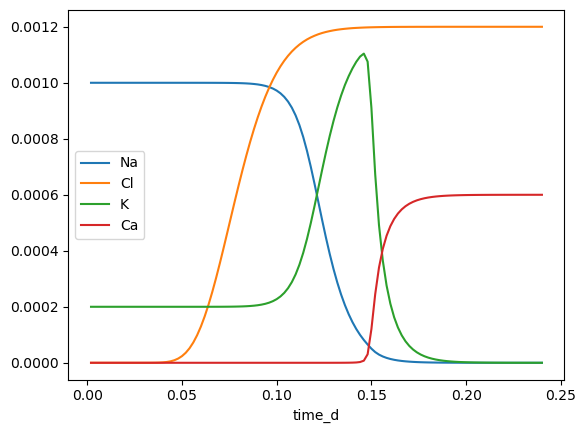

In [33]:
simdf[simdf.cell == 40].plot(y=['Na', 'Cl', 'K', 'Ca'])

<Axes: xlabel='time', ylabel='mmols/kgw'>

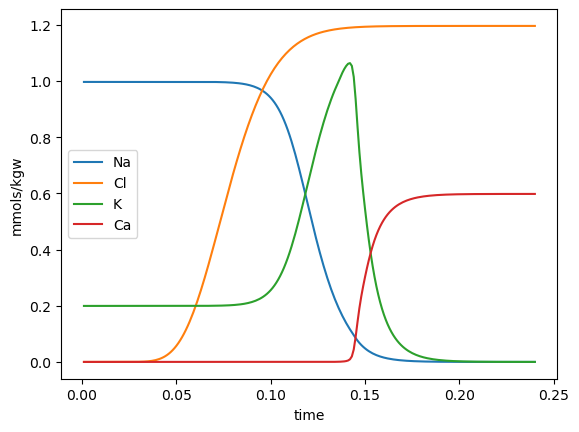

In [ ]:
plot(
    model_name='cat_ex_1d',
    component_models_dir=Path('/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/rtmf6/.internal/component_models'))

In [ ]:
df_rtmf6 = read_conc(
    model_name='cat_ex_1d',
    component_models_dir=Path('/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/rtmf6/.internal/component_models'))

In [62]:
df

,Na,Cl,K,Ca
time,,,,
0.001,0.996999,0.000000e+00,0.199400,1.981313e-17
0.002,0.996999,1.217936e-13,0.199400,3.976317e-17
0.003,0.996999,6.583367e-13,0.199400,6.005352e-17
0.004,0.996999,2.394274e-12,0.199400,8.291046e-17
0.005,0.996999,7.601381e-12,0.199400,1.155372e-16
...,...,...,...,...
0.236,0.000015,1.196419e+00,0.000053,5.981804e-01
0.237,0.000014,1.196419e+00,0.000049,5.981826e-01
0.238,0.000014,1.196419e+00,0.000045,5.981846e-01
